# Visualizing categorical data
  
In the `relational plot tutorial` we saw how to use different visual representations to show the relationship between multiple variables in a dataset. In the examples, we focused on cases where the main relationship was between two numerical variables. If one of the main variables is "categorical" (divided into discrete groups) it may be helpful to use a more specialized approach to visualization.

In seaborn, there are several different ways to visualize a relationship involving categorical data. Similar to the relationship between `relplot` and either `scatterplot` or `lineplot`, there are two ways to make these plots. There are a number of axes-level functions for plotting categorical data in different ways and a figure-level interface, `catplot`, that gives unified higher-level access to them.

It's helpful to think of the different categorical plot kinds as belonging to three different families, which we'll discuss in detail below. They are:

Categorical scatterplots:

- `stripplot` (with ``kind="strip"``; the default)
- `swarmplot` (with ``kind="swarm"``)

Categorical distribution plots:

- `boxplot` (with ``kind="box"``)
- `violinplot` (with ``kind="violin"``)
- `boxenplot` (with ``kind="boxen"``)

Categorical estimate plots:

- `pointplot` (with ``kind="point"``)
- `barplot` (with ``kind="bar"``)
- `countplot` (with ``kind="count"``)

These families represent the data using different levels of granularity. When deciding which to use, you'll have to think about the question that you want to answer. The unified API makes it easy to switch between different kinds and see your data from several perspectives.

In this tutorial, we'll mostly focus on the figure-level interface, `catplot`. Remember that this function is a higher-level interface each of the functions above, so we'll reference them when we show each kind of plot, keeping the more verbose kind-specific API documentation at hand.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", color_codes=True)
np.random.seed(sum(map(ord, "categorical")))

## Categorical scatterplots
------------------------

The default representation of the data in `catplot` uses a scatterplot, but Seaborn has two categorical scatter plots methods. They take different approaches to resolving the main challenge in representing categorical data with a scatter plot--all of the points belonging to one category would fall on the same position along the axis corresponding to the categorical variable. The approach used by `stripplot`, which is the default "kind" in `catplot` is to adjust the positions of points on the categorical axis with a small amount of random "jitter":

In [2]:
tips = sns.load_dataset("tips")
print(tips.info())
tips.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


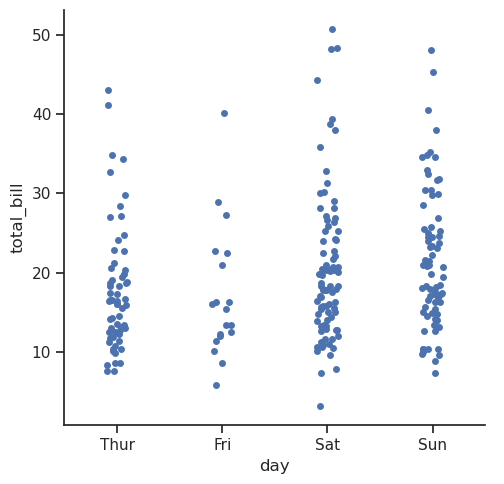

In [3]:
# Create a categorical plot of total bill by day
sns.catplot(data=tips, x="day", y="total_bill") #dataframe, x-axis column name, y-axis column name, notice how the default plot is a strip plot which jitters the data

The ``jitter`` parameter controls the magnitude of jitter or disables it altogether:

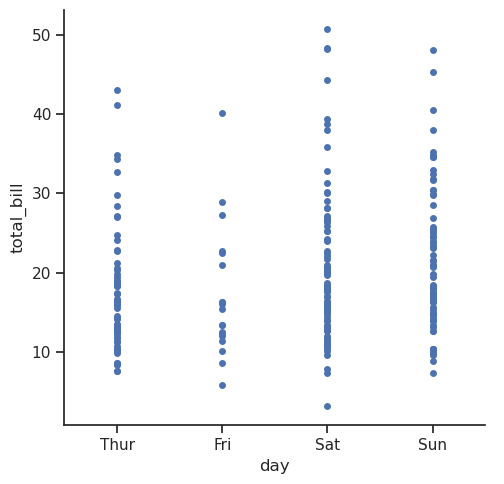

In [4]:
# Create a categorical plot of total bill by day without jitter
sns.catplot(data=tips, x="day", y="total_bill", #dataframe, x-axis column name, y-axis column name
            jitter=False) #turn off jittering to see overlapping points

The second approach adjusts the points along the categorical axis using an algorithm that prevents them from overlapping. It can give a better representation of the distribution of observations, although it only works well for relatively small datasets. This kind of plot is sometimes called a "beeswarm" and is drawn in seaborn by `swarmplot`, which is activated by setting ``kind="swarm"`` in `catplot`:

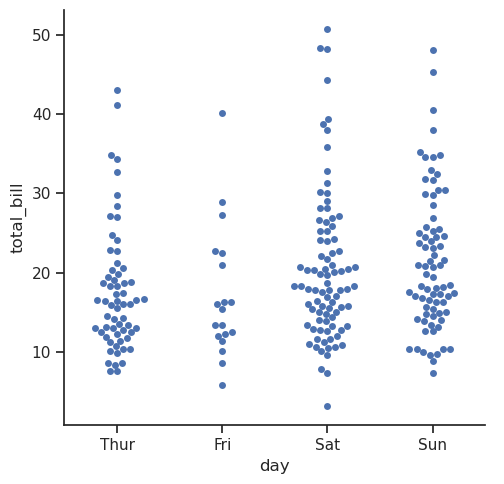

In [ ]:
# Create a categorical plot of total bill by day with swarm plot
sns.catplot(data=tips, x="day", y="total_bill", #dataframe, x-axis column name, y-axis column name
            kind="swarm") #use kind="swarm" to create a swarm plot, similar to jitter = True but better at avoiding overlap

Similar to the relational plots, it's possible to add another dimension to a categorical plot by using a ``hue`` semantic. (The categorical plots do not currently support ``size`` or ``style`` semantics). Each different categorical plotting function handles the ``hue`` semantic differently. For the scatter plots, it is only necessary to change the color of the points:

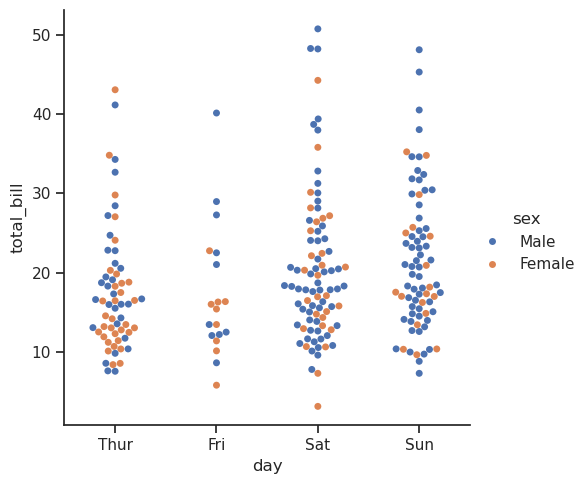

In [6]:
# Create a categorical plot of total bill by day with swarm
sns.catplot(data=tips, x="day", y="total_bill",  #dataframe, x-axis column name, y-axis column name
            hue="sex", #set the hue to sex
            kind="swarm") #use kind="swarm" to create a swarm plot, similar to jitter = True but better at avoiding overlap

Unlike with numerical data, it is not always obvious how to order the levels of the categorical variable along its axis. In general, the seaborn categorical plotting functions try to infer the order of categories from the data. If your data have a pandas ``Categorical`` datatype, then the default order of the categories can be set there. If the variable passed to the categorical axis looks numerical, the levels will be sorted. But, by default, the data are still treated as categorical and drawn at ordinal positions on the categorical axes (specifically, at 0, 1, ...) even when numbers are used to label them:

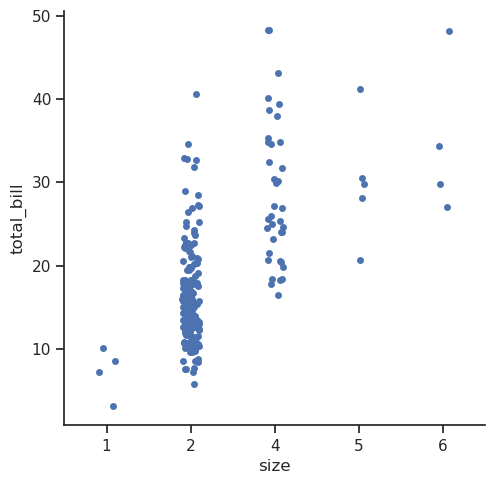

In [ ]:
# Create a categorical plot of total bill by size excluding size 3
sns.catplot(data=tips.query("size != 3"), #dataframe filtered to exclude size 3 the != means not equal to
            x="size", y="total_bill", #dataframe, x-axis column name, y-axis column name
            #kind="swarm" #use kind="swarm" to create a swarm plot, similar to jitter = True but better at avoiding overlap, what happens?
            )

Alll categorical plotting functions have a `native_scale` parameter, which can be set to `True` when you want to use numeric or datetime data for categorical grouping without changing the underlying data properties: 

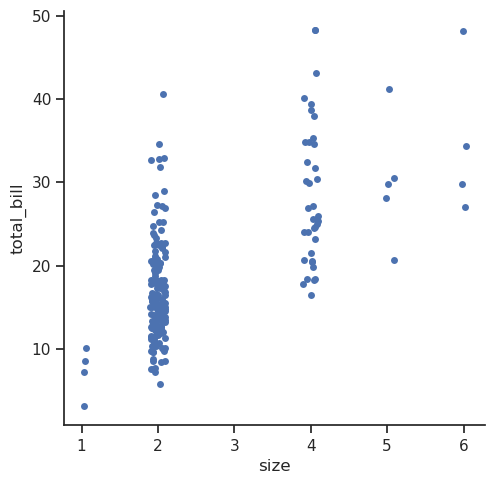

In [ ]:
# Create a categorical plot of total bill by size excluding size 3 with native scale
sns.catplot(data=tips.query("size != 3"), #dataframe filtered to exclude size 3 the != means not equal to
            x="size", y="total_bill", #dataframe, x-axis column name, y-axis column name
            native_scale=True)#use native_scale=True to adjust the width of the points based on the number of observations in each category, now 3 appears

The other option for choosing a default ordering is to take the levels of the category as they appear in the dataset. The ordering can also be controlled on a plot-specific basis using the ``order`` parameter. This can be important when drawing multiple categorical plots in the same figure, which we'll see more of below:

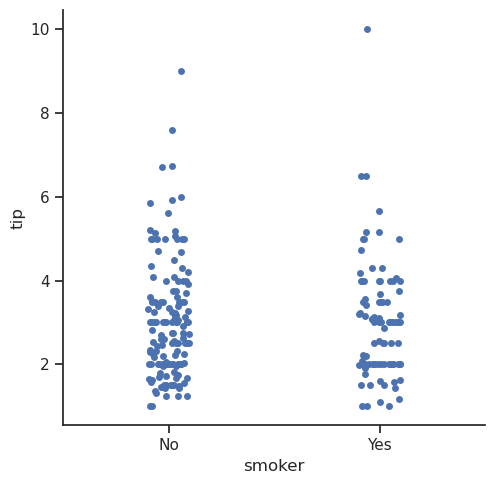

In [ ]:
# Create a categorical plot of tip by smoker with custom order
sns.catplot(data=tips, x="smoker", y="tip",  #dataframe, x-axis column name, y-axis column name
            order=["No", "Yes"]) #set custom order for the x-axis categories, put no first and yes second

We've referred to the idea of "categorical axis". In these examples, that's always corresponded to the horizontal axis. But it's often helpful to put the categorical variable on the vertical axis (particularly when the category names are relatively long or there are many categories). To do this, swap the assignment of variables to axes:

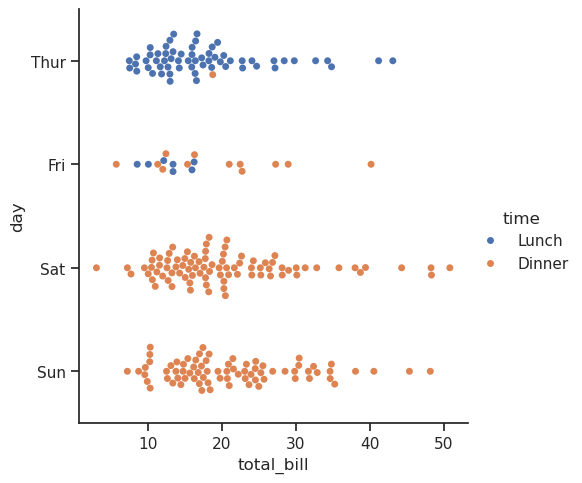

In [ ]:
# Create a categorical plot of total bill by day with swarm plot and time hue, swap axes
sns.catplot(data=tips, x="total_bill", y="day", #dataframe, x-axis column name, y-axis column name, we swapped the x and y axes
            hue="time", #set the hue to time
            kind="swarm" #use kind="swarm" to create a swarm plot, similar to jitter = True but better at avoiding overlap
            )

## Comparing distributions
-----------------------

As the size of the dataset grows, categorical scatter plots become limited in the information they can provide about the distribution of values within each category. When this happens, there are several approaches for summarizing the distributional information in ways that facilitate easy comparisons across the category levels.

### Boxplots

The first is the familiar `boxplot`. This kind of plot shows the three quartile values of the distribution along with extreme values. The "whiskers" extend to points that lie within 1.5 IQRs of the lower and upper quartile, and then observations that fall outside this range are displayed independently. This means that each value in the boxplot corresponds to an actual observation in the data.

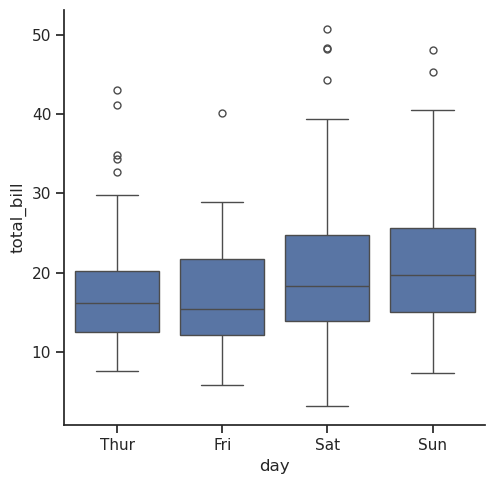

In [ ]:
# Create a categorical plot of total bill by day with box plot
sns.catplot(data=tips, x="day", y="total_bill",
            kind="box"
            )

When adding a ``hue`` semantic, the box for each level of the semantic variable is made narrower and shifted along the categorical axis:

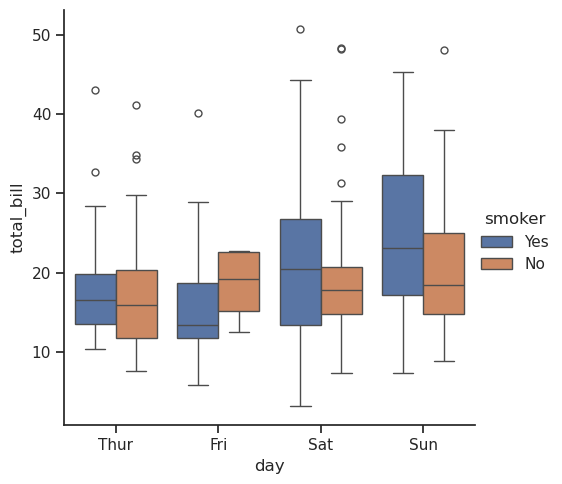

In [ ]:
# Create a categorical plot of total bill by day with box plot
sns.catplot(data=tips, x="day", y="total_bill", #dataframe, x-axis column name, y-axis column name
            hue="smoker", #set the hue to smoker, creating two box plots per day    
            kind="box" #use kind="box" to create a box plot
            )

This behavior is called "dodging", and it is controlled by the `dodge` parameter, elements dodge only if they would otherwise overlap:

In [15]:
#data maniputalation
tips["weekend"] = tips["day"].isin(["Sat", "Sun"]) #create a new column 'weekend' that is True if the day is Saturday or Sunday
tips.head()

,total_bill,tip,sex,smoker,day,time,size,weekend
0,16.99,1.01,Female,No,Sun,Dinner,2,True
1,10.34,1.66,Male,No,Sun,Dinner,3,True
2,21.01,3.50,Male,No,Sun,Dinner,3,True
3,23.68,3.31,Male,No,Sun,Dinner,2,True
4,24.59,3.61,Female,No,Sun,Dinner,4,True


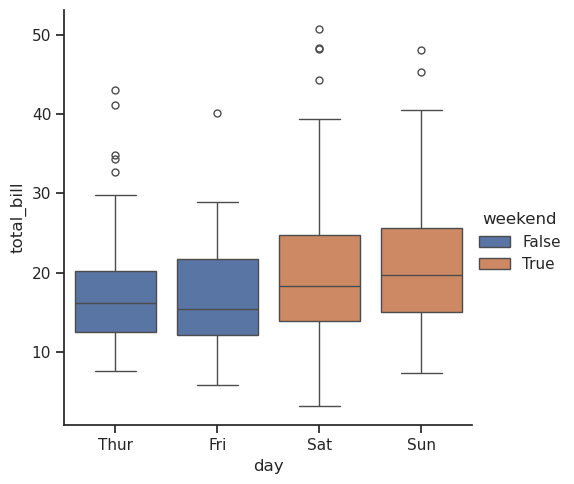

In [ ]:
# Create a categorical plot of total bill by day with box plot
sns.catplot(data=tips, x="day", y="total_bill",  #dataframe, x-axis column name, y-axis column name
            hue="weekend", #set the hue to weekend, creating two box plots per day
            kind="box")#use kind="box" to create a box plot  Note, there was no overlap because weekend is perfectly correlated with day

A related function, `boxenplot`, draws a plot that is similar to a box plot but optimized for showing more information about the shape of the distribution. It is best suited for larger datasets:

In [17]:
diamonds = sns.load_dataset("diamonds")
print(diamonds.info())
diamonds.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
sns.catplot(
    data=diamonds.sort_values("color"),
    x="color", y="price", kind="boxen",
)

## Violinplots


A different approach is a `violinplot`, which combines a boxplot with the kernel density estimation procedure described in the `distributions` tutorial:

In [ ]:
sns.catplot(
    data=tips, x="total_bill", y="day", hue="sex", kind="violin",
)

This approach uses the kernel density estimate to provide a richer description of the distribution of values. Additionally, the quartile and whisker values from the boxplot are shown inside the violin. The downside is that, because the violinplot uses a KDE, there are some other parameters that may need tweaking, adding some complexity relative to the straightforward boxplot:

In [ ]:
sns.catplot(
    data=tips, x="total_bill", y="day", hue="sex",
    kind="violin", bw_adjust=.5, cut=0,
)

It's also possible to "split" the violins, which can allow for a more efficient use of space:

In [ ]:
sns.catplot(
    data=tips, x="day", y="total_bill", hue="sex",
    kind="violin", split=True,
)

Finally, there are several options for the plot that is drawn on the interior of the violins, including ways to show each individual observation instead of the summary boxplot values:

In [ ]:
sns.catplot(
    data=tips, x="day", y="total_bill", hue="sex",
    kind="violin", inner="stick", split=True, palette="pastel",
)

It can also be useful to combine `swarmplot` or `stripplot` with a box plot or violin plot to show each observation along with a summary of the distribution:

In [ ]:
g = sns.catplot(data=tips, x="day", y="total_bill", kind="violin", inner=None)
sns.swarmplot(data=tips, x="day", y="total_bill", color="k", size=3, ax=g.ax)

## Estimating central tendency
---------------------------

For other applications, rather than showing the distribution within each category, you might want to show an estimate of the central tendency of the values. Seaborn has two main ways to show this information. Importantly, the basic API for these functions is identical to that for the ones discussed above.

### Bar plots

A familiar style of plot that accomplishes this goal is a bar plot. In seaborn, the `barplot` function operates on a full dataset and applies a function to obtain the estimate (taking the mean by default). When there are multiple observations in each category, it also uses bootstrapping to compute a confidence interval around the estimate, which is plotted using error bars:

In [ ]:
titanic = sns.load_dataset("titanic")
sns.catplot(data=titanic, x="sex", y="survived", hue="class", kind="bar")

The default error bars show 95% confidence intervals, but (starting in v0.12), it is possible to select from a number of other representations:

In [ ]:
sns.catplot(data=titanic, x="age", y="deck", errorbar=("pi", 95), kind="bar")

A special case for the bar plot is when you want to show the number of observations in each category rather than computing a statistic for a second variable. This is similar to a histogram over a categorical, rather than quantitative, variable. In seaborn, it's easy to do so with the `countplot` function:

In [ ]:
sns.catplot(data=titanic, x="deck", kind="count")

Both `barplot` and `countplot` can be invoked with all of the options discussed above, along with others that are demonstrated in the detailed documentation for each function:

In [ ]:
sns.catplot(
    data=titanic, y="deck", hue="class", kind="count",
    palette="pastel", edgecolor=".6",
)

## Point plots

An alternative style for visualizing the same information is offered by the `pointplot` function. This function also encodes the value of the estimate with height on the other axis, but rather than showing a full bar, it plots the point estimate and confidence interval. Additionally, `pointplot` connects points from the same ``hue`` category. This makes it easy to see how the main relationship is changing as a function of the hue semantic, because your eyes are quite good at picking up on differences of slopes:

In [ ]:
sns.catplot(data=titanic, x="sex", y="survived", hue="class", kind="point")

While the categorical functions lack the ``style`` semantic of the relational functions, it can still be a good idea to vary the marker and/or linestyle along with the hue to make figures that are maximally accessible and reproduce well in black and white:

In [ ]:
sns.catplot(
    data=titanic, x="class", y="survived", hue="sex",
    palette={"male": "g", "female": "m"},
    markers=["^", "o"], linestyles=["-", "--"],
    kind="point"
)

## Showing additional dimensions
-----------------------------

Just like `relplot`, the fact that `catplot` is built on a `FacetGrid` means that it is easy to add faceting variables to visualize higher-dimensional relationships:

In [ ]:
sns.catplot(
    data=tips, x="day", y="total_bill", hue="smoker",
    kind="swarm", col="time", aspect=.7,
)

For further customization of the plot, you can use the methods on the `FacetGrid` object that it returns:

In [ ]:
g = sns.catplot(
    data=titanic,
    x="fare", y="embark_town", row="class",
    kind="box", orient="h",
    sharex=False, margin_titles=True,
    height=1.5, aspect=4,
)
g.set(xlabel="Fare", ylabel="")
g.set_titles(row_template="{row_name} class")
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter('${x:.0f}')

Now we will explore [Multiplot Grids](./axis_grids.ipynb)